# Character-Level GPT on TinyStories — From-Scratch Implementation

A decoder-only Transformer (GPT-style) built directly from tensor operations and trained at the character level on TinyStories. The model doesn't use any prebuilt Transformer or attention module (`nn.Transformer`, `nn.MultiheadAttention`, `scaled_dot_product_attention`). Attention, masking, layer norm, the feed-forward blocks and generation are all written out here.

| Section | Content |
|---|---|
| 0 | Environment and run setup (raw log, environment file) |
| 1 | Data preprocessing — loading, personal 100K/10K split, character vocabulary, input–target sequences |
| 2 | GPT model — LayerNorm, causal multi-head self-attention, FFN, residual blocks, embeddings, LM head |
| 3 | Training — cross-entropy, AdamW, warm-up + cosine schedule, stability monitoring, checkpoints |
| 4 | Loss curves |
| 5 | Text generation — greedy and temperature sampling |
| 6 | Evaluation metrics and `metrics.md` |
| 7 | Failure analysis |
| 8 | Run manifest |

Every run writes to `runs/<run_id>/`. The run writes `train.log` once and doesn't edit it afterwards; it is the evidence trail.

## 0. Environment Setup

In [1]:
%pip install -q datasets

### 0.1 Imports

In [2]:
import os, re, sys, json, math, time, random, hashlib, logging, platform, subprocess, unicodedata
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import datasets
from datasets import load_dataset

### 0.2 Device and Mixed Precision

The run uses bfloat16 autocast on Ampere or newer GPUs. On older cards such as the T4 or V100, it uses float16 with a gradient scaler. TF32 is turned on for the float32 matmuls that remain.

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  "
          f"memory: {torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB  |  amp: {amp_dtype}")
else:
    amp_dtype = torch.float32
    print("No GPU found, running on CPU")


def amp_ctx():
    return torch.autocast(device_type="cuda", dtype=amp_dtype) if device == "cuda" else nullcontext()


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

GPU: NVIDIA A100-SXM4-80GB  |  memory: 79.3 GiB  |  amp: torch.bfloat16


### 0.3 Run Configuration

The default model has 6 layers, 6 heads, 384-dim embeddings and a 256-character context, which comes to about 10.7M parameters. Each optimizer step sees 128 × 256 = 32,768 characters.

In [4]:
@dataclass
class Config:
    dataset_name: str = "roneneldan/TinyStories"
    seed: int = 1337
    n_train_stories: int = 100_000
    n_val_stories: int = 10_000
    min_story_chars: int = 50
    min_char_freq: int = 20

    block_size: int = 256
    n_layer: int = 6
    n_head: int = 6
    n_embd: int = 384
    dropout: float = 0.1

    epochs: int = 10
    batch_size: int = 128
    peak_lr: float = 1e-3
    min_lr: float = 1e-4
    warmup_frac: float = 0.03
    weight_decay: float = 0.1
    beta1: float = 0.9
    beta2: float = 0.95
    grad_clip: float = 1.0
    spike_factor: float = 1.3

    log_every: int = 50
    eval_interval: int = 500
    eval_batches: int = 40
    final_train_eval_batches: int | None = None
    keep_epoch_weights: bool = True
    compile: bool = True
    out_root: str = "runs"


cfg = Config()
set_seed(cfg.seed)
pd.Series(asdict(cfg), name="value").to_frame()

,value
dataset_name,roneneldan/TinyStories
seed,1337
n_train_stories,100000
n_val_stories,10000
min_story_chars,50
min_char_freq,20
block_size,256
n_layer,6
n_head,6
n_embd,384


### 0.4 Run Directory and Raw Log

The log handler appends to the file and nothing in the notebook ever rewrites it.

In [5]:
run_id = datetime.now().strftime("%Y%m%d-%H%M%S") + f"_L{cfg.n_layer}H{cfg.n_head}C{cfg.n_embd}T{cfg.block_size}"
run_dir = Path(cfg.out_root) / run_id
for sub in ("checkpoints", "plots", "samples"):
    (run_dir / sub).mkdir(parents=True, exist_ok=True)

log = logging.getLogger("gpt")
log.setLevel(logging.INFO)
log.handlers.clear()
log.propagate = False
fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%Y-%m-%d %H:%M:%S")
for handler in (logging.FileHandler(run_dir / "train.log", mode="a"), logging.StreamHandler(sys.stdout)):
    handler.setFormatter(fmt)
    log.addHandler(handler)

log.info(f"run_id={run_id}")
log.info(f"device={device} amp_dtype={amp_dtype}")
log.info("config=" + json.dumps(asdict(cfg)))

2026-10-05 21:46:55 | INFO    | run_id=20261005-214655_L6H6C384T256
2026-10-05 21:46:55 | INFO    | device=cuda amp_dtype=torch.bfloat16
2026-10-05 21:46:55 | INFO    | config={"dataset_name": "roneneldan/TinyStories", "seed": 1337, "n_train_stories": 100000, "n_val_stories": 10000, "min_story_chars": 50, "min_char_freq": 20, "block_size": 256, "n_layer": 6, "n_head": 6, "n_embd": 384, "dropout": 0.1, "epochs": 10, "batch_size": 128, "peak_lr": 0.001, "min_lr": 0.0001, "warmup_frac": 0.03, "weight_decay": 0.1, "beta1": 0.9, "beta2": 0.95, "grad_clip": 1.0, "spike_factor": 1.3, "log_every": 50, "eval_interval": 500, "eval_batches": 40, "final_train_eval_batches": null, "keep_epoch_weights": true, "compile": true, "out_root": "runs"}


### 0.5 Environment File and Library Versions

In [6]:
env_info = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version() if device == "cuda" else None,
    "gpu": torch.cuda.get_device_name(0) if device == "cuda" else None,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "datasets": datasets.__version__,
    "amp_dtype": str(amp_dtype),
}
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
(run_dir / "requirements-lock.txt").write_text(freeze)
(run_dir / "env_info.json").write_text(json.dumps(env_info, indent=2))
log.info("env=" + json.dumps(env_info))
env_info

2026-10-05 21:46:57 | INFO    | env={"python": "3.13.15", "platform": "Linux-6.6.122+-x86_64-with-glibc2.39", "torch": "2.11.0+cu130", "cuda": "13.0", "cudnn": 92700, "gpu": "NVIDIA A100-SXM4-80GB", "numpy": "2.1.3", "pandas": "2.2.3", "matplotlib": "3.10.0", "datasets": "4.8.5", "amp_dtype": "torch.bfloat16"}


{'python': '3.13.15',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'torch': '2.11.0+cu130',
 'cuda': '13.0',
 'cudnn': 92700,
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'matplotlib': '3.10.0',
 'datasets': '4.8.5',
 'amp_dtype': 'torch.bfloat16'}

## 1. Data Preprocessing

### 1.1 Load TinyStories

TinyStories (Eldan & Li, 2023) is a set of short synthetic stories written with the vocabulary of a 3–4 year old. The Hugging Face release has about 2.1M training stories and 22K validation stories, each in a single `text` field.

In [7]:
raw = load_dataset(cfg.dataset_name, split="train")
log.info(f"loaded {cfg.dataset_name}: {len(raw):,} stories, columns={raw.column_names}")
raw

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

2026-10-05 21:47:21 | INFO    | loaded roneneldan/TinyStories: 2,119,719 stories, columns=['text']


Dataset({
    features: ['text'],
    num_rows: 2119719
})

### 1.2 A First Look at the Raw Data

In [8]:
peek = raw.select(range(2000))["text"]
peek_len = np.array([len(t) for t in peek])
print(f"chars per story (first 2000): mean={peek_len.mean():.0f}  median={np.median(peek_len):.0f}  "
      f"min={peek_len.min()}  max={peek_len.max()}")
odd = sorted({ch for t in peek for ch in t if not ch.isascii()})
print("non-ASCII characters seen:", odd[:40])
print("-" * 80)
print(peek[0])

chars per story (first 2000): mean=850  median=777  min=274  max=4123
non-ASCII characters seen: ['¦', 'â', 'œ', '˜', '“', '”', '€', '™']
--------------------------------------------------------------------------------
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


### 1.3 Text Normalisation

The raw stories mix curly and straight quotes, use several kinds of dash, and sometimes contain stray control or zero-width characters. Normalising these before building the vocabulary keeps the character set small, and none of the changes alter the meaning of the text.

In [9]:
PUNCT_MAP = str.maketrans({
    "‘": "'", "’": "'", "‚": "'", "′": "'",
    "“": '"', "”": '"', "„": '"', "″": '"',
    "–": "-", "—": "-", "−": "-",
    "…": "...", "\u00a0": " ", "\t": " ", "\r": "\n",
})
CONTROL_RE = re.compile(r"[\x00-\x08\x0b-\x1f\x7f-\x9f\u200b-\u200f\ufeff\n]")


def normalize(text):
    text = unicodedata.normalize("NFKC", text).translate(PUNCT_MAP)
    text = CONTROL_RE.sub("", text)
    text = re.sub(r"[ ]{2,}", " ", text)
    text = re.sub(r" *\n *", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


normalize("“Hello!”  said   Tom — it’s fun…\r\n\r\n\r\nThe end.")

'"Hello!" said Tom - it\'s fun...The end.'

### 1.4 Personal Train / Validation Split (100K / 10K)

The split is drawn from the official *train* partition with this run's seed: a random permutation, then normalisation, then removal of empty or exact-duplicate stories. The first 100,000 unique stories become training data and the next 10,000 become validation data, so the two sets are disjoint. The chosen indices are saved so the split can be rebuilt exactly.

In [10]:
need = cfg.n_train_stories + cfg.n_val_stories
perm = np.random.default_rng(cfg.seed).permutation(len(raw))
seen, kept_idx, kept_text = set(), [], []
cursor, chunk = 0, int(need * 1.1)
while len(kept_text) < need and cursor < len(perm):
    ids = perm[cursor:cursor + chunk]
    cursor += len(ids)
    for i, story in zip(ids, raw.select(ids)["text"]):
        story = normalize(story)
        if len(story) < cfg.min_story_chars or story in seen:
            continue
        seen.add(story)
        kept_idx.append(int(i))
        kept_text.append(story)
        if len(kept_text) == need:
            break
assert len(kept_text) == need, f"only {len(kept_text)} usable stories found"

train_stories, val_stories = kept_text[: cfg.n_train_stories], kept_text[cfg.n_train_stories:]
train_idx, val_idx = kept_idx[: cfg.n_train_stories], kept_idx[cfg.n_train_stories:]
assert not set(train_idx) & set(val_idx)

(run_dir / "split_indices.json").write_text(json.dumps({"seed": cfg.seed, "train": train_idx, "val": val_idx}))
log.info(f"split: train={len(train_stories):,} val={len(val_stories):,} "
         f"(scanned {cursor:,} shuffled stories, seed={cfg.seed})")

2026-10-05 21:47:37 | INFO    | split: train=100,000 val=10,000 (scanned 121,000 shuffled stories, seed=1337)


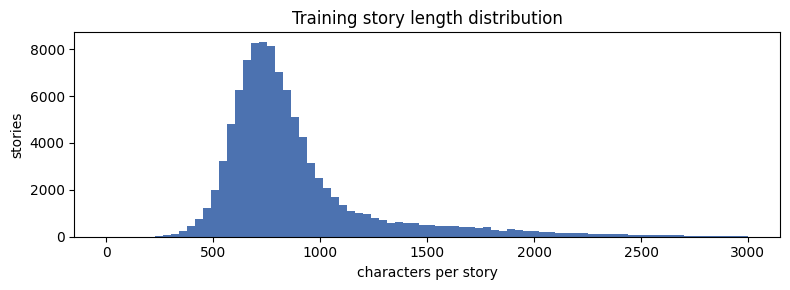

,train,val
count,100000.0,10000.0
mean,888.4,890.9
std,394.9,401.5
min,223.0,248.0
25%,666.0,666.0
50%,781.0,782.0
75%,948.0,948.0
max,4287.0,4124.0


In [11]:
lengths = pd.DataFrame({
    "train": pd.Series([len(s) for s in train_stories]).describe(),
    "val": pd.Series([len(s) for s in val_stories]).describe(),
}).round(1)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist([len(s) for s in train_stories], bins=80, range=(0, 3000), color="#4C72B0")
ax.set_xlabel("characters per story")
ax.set_ylabel("stories")
ax.set_title("Training story length distribution")
plt.tight_layout()
plt.savefig(run_dir / "plots" / "story_lengths.png", dpi=120)
plt.show()
lengths

### 1.5 Character Vocabulary — `char_to_idx` / `idx_to_char`

The vocabulary comes from the training split only. Characters that appear fewer than `min_char_freq` times (stray emoji, foreign script) map to `<unk>`, so the model doesn't waste output capacity on them. Two special tokens are added:

- `<|eos|>` (id 0) marks story boundaries. It is placed between consecutive stories and at the start of every prompt at generation time.
- `<unk>` (id 1) stands in for any character outside the vocabulary.

In [12]:
EOS_CHAR = "\x03"
train_text = EOS_CHAR + EOS_CHAR.join(train_stories) + EOS_CHAR
val_text = EOS_CHAR + EOS_CHAR.join(val_stories) + EOS_CHAR

codepoints, counts = np.unique(np.frombuffer(train_text.encode("utf-32-le"), dtype=np.uint32), return_counts=True)
char_counts = {chr(c): int(n) for c, n in zip(codepoints, counts) if chr(c) != EOS_CHAR}

vocab_chars = sorted(ch for ch, n in char_counts.items() if n >= cfg.min_char_freq)
dropped = {ch: n for ch, n in char_counts.items() if n < cfg.min_char_freq}

EOS_ID, UNK_ID = 0, 1
char_to_idx = {EOS_CHAR: EOS_ID}
char_to_idx.update({ch: i + 2 for i, ch in enumerate(vocab_chars)})
idx_to_char = {EOS_ID: "<|eos|>", UNK_ID: "�"}
idx_to_char.update({i: ch for ch, i in char_to_idx.items() if i >= 2})
vocab_size = len(idx_to_char)

coverage = 1 - sum(dropped.values()) / sum(char_counts.values())
log.info(f"vocab_size={vocab_size} kept_chars={len(vocab_chars)} dropped_chars={len(dropped)} coverage={coverage:.6%}")
print(repr("".join(vocab_chars)))

2026-10-05 21:47:39 | INFO    | vocab_size=83 kept_chars=81 dropped_chars=20 coverage=99.999868%
' !"\',-./012345689:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz¦©\xadÂÃâœ̃€'


### 1.6 Integer Encoding

`encode` and `decode` are the plain dictionary lookups. To encode the full corpus (about 90M characters) the same mapping is applied through a code-point lookup table in NumPy, which is much faster than a Python loop.

In [13]:
lut = np.full(max(map(ord, char_to_idx)) + 1, UNK_ID, dtype=np.int16)
for ch, i in char_to_idx.items():
    lut[ord(ch)] = i


def encode(text):
    return [char_to_idx.get(ch, UNK_ID) for ch in text]


def decode(ids):
    return "".join(idx_to_char[int(i)] for i in ids)


def encode_corpus(text):
    cps = np.frombuffer(text.encode("utf-32-le"), dtype=np.uint32)
    ids = np.full(cps.shape, UNK_ID, dtype=np.int16)
    inside = cps < lut.size
    ids[inside] = lut[cps[inside]]
    return ids


sample = train_stories[0][:120]
assert decode(encode(sample)) == sample
assert np.array_equal(encode_corpus(sample), np.array(encode(sample), dtype=np.int16))
print(encode(sample)[:30])

[36, 61, 50, 52, 2, 68, 63, 62, 61, 2, 48, 2, 67, 56, 60, 52, 6, 2, 67, 55, 52, 65, 52, 2, 70, 48, 66, 2, 48, 2]


In [14]:
train_np, val_np = encode_corpus(train_text), encode_corpus(val_text)
train_data = torch.from_numpy(train_np).to(device)
val_data = torch.from_numpy(val_np).to(device)

data_stats = {
    "train_chars": len(train_np),
    "val_chars": len(val_np),
    "train_unk_rate": float((train_np == UNK_ID).mean()),
    "val_unk_rate": float((val_np == UNK_ID).mean()),
}
(run_dir / "vocab.json").write_text(json.dumps({"idx_to_char": idx_to_char, "eos_id": EOS_ID, "unk_id": UNK_ID}, indent=1))
log.info("data " + json.dumps(data_stats))
data_stats

2026-10-05 21:47:40 | INFO    | data {"train_chars": 88938739, "val_chars": 8919002, "train_unk_rate": 1.3155122426460308e-06, "val_unk_rate": 2.130283186392379e-06}


{'train_chars': 88938739,
 'val_chars': 8919002,
 'train_unk_rate': 1.3155122426460308e-06,
 'val_unk_rate': 2.130283186392379e-06}

### 1.7 Fixed-Length Input–Target Sequences

The corpus is a single stream of character ids. A training example is a window of `block_size + 1` ids. The first `block_size` ids are the input `x` and the same window shifted by one position is the target `y`, so position *t* is trained to predict character *t+1*.

Each epoch cuts the stream into non-overlapping windows. The starting offset is random (0 to `block_size − 1`) and the windows are shuffled, so every epoch covers every training character exactly once, with window boundaries that differ from one epoch to the next. Batches are gathered directly on the GPU, with no DataLoader overhead.

In [15]:
class SequenceBatcher:
    def __init__(self, data, block_size, batch_size, seed):
        self.data, self.T, self.B = data, block_size, batch_size
        self.n_windows = (len(data) - block_size) // block_size
        self.steps_per_epoch = self.n_windows // batch_size
        self.gen = torch.Generator().manual_seed(seed)
        self.span = torch.arange(block_size + 1, device=data.device)

    def batch(self, starts):
        chunk = self.data[starts[:, None] + self.span].long()
        return chunk[:, :-1], chunk[:, 1:]

    def epoch(self):
        offset = int(torch.randint(0, self.T, (1,), generator=self.gen))
        order = torch.randperm(self.n_windows, generator=self.gen)
        starts = (offset + order * self.T).to(self.data.device)
        for s in range(self.steps_per_epoch):
            yield self.batch(starts[s * self.B:(s + 1) * self.B])


def eval_starts(data, block_size, batch_size, max_batches=None, seed=0):
    n = (len(data) - block_size) // block_size
    starts = torch.arange(n) * block_size
    if max_batches is not None and max_batches * batch_size < n:
        g = torch.Generator().manual_seed(seed)
        starts = starts[torch.randperm(n, generator=g)[: max_batches * batch_size]]
    starts = starts[: len(starts) // batch_size * batch_size]
    return starts.to(data.device)


train_batcher = SequenceBatcher(train_data, cfg.block_size, cfg.batch_size, cfg.seed)
log.info(f"windows/epoch={train_batcher.n_windows:,} steps/epoch={train_batcher.steps_per_epoch:,} "
         f"tokens/step={cfg.batch_size * cfg.block_size:,}")

2026-10-05 21:47:40 | INFO    | windows/epoch=347,415 steps/epoch=2,714 tokens/step=32,768


In [16]:
xb, yb = next(train_batcher.epoch())
print("x shape:", tuple(xb.shape), " y shape:", tuple(yb.shape))
assert torch.equal(xb[:, 1:], yb[:, :-1])
print("x:", repr(decode(xb[0, :60].tolist())))
print("y:", repr(decode(yb[0, :60].tolist())))

x shape: (128, 256)  y shape: (128, 256)
x: ' her mom angry. She said, "But I like it. It\'s shiny and spa'
y: 'her mom angry. She said, "But I like it. It\'s shiny and spar'


## 2. GPT Model Implementation

This is a pre-norm decoder-only Transformer, following the GPT-2 layout:

```
tokens ─► token embedding + positional embedding ─► dropout
       ─► N × [ x = x + MHSA(LN(x)) ;  x = x + FFN(LN(x)) ]
       ─► final LN ─► linear LM head ─► logits over the vocabulary
```

### 2.1 Layer Normalization

Each vector is normalised over its feature dimension and then given a learned scale and shift: $\mathrm{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$.

In [17]:
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
        self.bias = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = (x - mean).pow(2).mean(dim=-1, keepdim=True)
        return (x - mean) * torch.rsqrt(var + self.eps) * self.weight + self.bias

### 2.2 Causal Multi-Head Self-Attention

$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$, where $M_{ij} = -\infty$ for $j > i$.

One fused linear layer produces Q, K and V for all heads at once, and the result is split into `n_head` heads of size `n_embd / n_head`. A lower-triangular boolean mask, stored as a buffer, sets the scores for future positions to −∞ before the softmax, so their weights are exactly zero. The softmax runs in float32 for numerical stability under mixed precision.

In [18]:
class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.n_embd % cfg.n_head == 0
        self.n_head = cfg.n_head
        self.head_dim = cfg.n_embd // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.head_dim)
        self.qkv = nn.Linear(cfg.n_embd, 3 * cfg.n_embd)
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.resid_drop = nn.Dropout(cfg.dropout)
        causal = torch.tril(torch.ones(cfg.block_size, cfg.block_size, dtype=torch.bool))
        self.register_buffer("causal_mask", causal.view(1, 1, cfg.block_size, cfg.block_size), persistent=False)

    def forward(self, x, return_weights=False):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) * self.scale
        scores = scores.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))
        weights = F.softmax(scores.float(), dim=-1).to(v.dtype)

        out = self.attn_drop(weights) @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_drop(self.proj(out))
        return (out, weights) if return_weights else out

### 2.3 Position-wise Feed-Forward Network

Two linear layers with a GELU between them, expanding to 4× the model width and projecting back.

In [19]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.n_embd, 4 * cfg.n_embd)
        self.proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.drop(self.proj(F.gelu(self.fc(x))))

### 2.4 Transformer Block with Residual Connections

The block uses pre-norm, with LayerNorm applied before each sub-layer. The residual path stays an identity, which makes deep stacks easy to optimise without the long warm-up a post-norm Transformer needs.

In [20]:
class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = LayerNorm(cfg.n_embd)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = LayerNorm(cfg.n_embd)
        self.ffn = FeedForward(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

### 2.5 GPT Language Model

- Learnable token embeddings `(vocab_size × n_embd)` and learnable absolute positional embeddings `(block_size × n_embd)`.
- A stack of `n_layer` blocks, then a final LayerNorm.
- A language-modelling head: a linear projection from `n_embd` to `vocab_size` that gives next-character logits at every position.

Weights are initialised from N(0, 0.02). The output projections of the residual branches are scaled by $1/\sqrt{2 \cdot n_{layer}}$ so the variance of the residual stream doesn't grow with depth (GPT-2).

In [21]:
class GPT(nn.Module):
    def __init__(self, cfg, vocab_size):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(vocab_size, cfg.n_embd)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith("proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layer))

    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.cfg.block_size, f"sequence length {T} exceeds block_size {self.cfg.block_size}"
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.float().view(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

### 2.6 Instantiate and Count Parameters

In [22]:
set_seed(cfg.seed)
raw_model = GPT(cfg, vocab_size).to(device)

n_params = sum(p.numel() for p in raw_model.parameters())
n_embed_params = raw_model.tok_emb.weight.numel() + raw_model.pos_emb.weight.numel()
param_table = pd.DataFrame(
    [(name, tuple(p.shape), p.numel()) for name, p in raw_model.named_parameters()],
    columns=["parameter", "shape", "count"],
)
log.info(f"parameters total={n_params:,} non_embedding={n_params - n_embed_params:,}")
print(f"total parameters: {n_params:,}   (non-embedding: {n_params - n_embed_params:,})")
param_table.head(16)

2026-10-05 21:47:41 | INFO    | parameters total=10,809,600 non_embedding=10,679,424
total parameters: 10,809,600   (non-embedding: 10,679,424)


,parameter,shape,count
0,tok_emb.weight,"(83, 384)",31872
1,pos_emb.weight,"(256, 384)",98304
2,blocks.0.ln1.weight,"(384,)",384
3,blocks.0.ln1.bias,"(384,)",384
4,blocks.0.attn.qkv.weight,"(1152, 384)",442368
5,blocks.0.attn.qkv.bias,"(1152,)",1152
6,blocks.0.attn.proj.weight,"(384, 384)",147456
7,blocks.0.attn.proj.bias,"(384,)",384
8,blocks.0.ln2.weight,"(384,)",384
9,blocks.0.ln2.bias,"(384,)",384


### 2.7 Verifying the Causal Mask

Two checks:

1. The attention weights in every head are exactly zero above the diagonal.
2. Changing future tokens leaves the logits at earlier positions unchanged. If the mask leaked, the logits before the edit point would change.

At initialisation the untrained model should also predict close to uniformly, giving a loss near $\ln(\text{vocab})$.

In [23]:
raw_model.eval()
with torch.no_grad():
    x = torch.randint(2, vocab_size, (2, 64), device=device)
    h = raw_model.drop(raw_model.tok_emb(x) + raw_model.pos_emb(torch.arange(64, device=device)))
    _, w = raw_model.blocks[0].attn(raw_model.blocks[0].ln1(h), return_weights=True)
    upper = torch.triu(torch.ones(64, 64, dtype=torch.bool, device=device), diagonal=1)
    assert w[..., upper].abs().max().item() == 0.0
    assert torch.allclose(w.sum(-1).float(), torch.ones_like(w.sum(-1)).float(), atol=1e-3)

    cut = 40
    x_edit = x.clone()
    x_edit[:, cut:] = torch.randint(2, vocab_size, (2, 64 - cut), device=device)
    a, _ = raw_model(x)
    b, _ = raw_model(x_edit)
    assert torch.allclose(a[:, :cut], b[:, :cut], atol=1e-5)
    assert not torch.allclose(a[:, cut:], b[:, cut:])

    _, init_loss = raw_model(xb[:8], yb[:8])
raw_model.train()
log.info(f"causal mask checks passed; initial loss={init_loss.item():.4f} (ln V={math.log(vocab_size):.4f})")

2026-10-05 21:47:41 | INFO    | causal mask checks passed; initial loss=4.5098 (ln V=4.4188)


## 3. Training

### 3.1 Optimizer

AdamW with β = (0.9, 0.95). Weight decay applies only to matrices (linear weights and embeddings). Biases and LayerNorm gains are left undecayed.

In [24]:
decay = [p for p in raw_model.parameters() if p.dim() >= 2]
no_decay = [p for p in raw_model.parameters() if p.dim() < 2]
optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": cfg.weight_decay}, {"params": no_decay, "weight_decay": 0.0}],
    lr=cfg.peak_lr, betas=(cfg.beta1, cfg.beta2), fused=(device == "cuda"),
)
scaler = torch.amp.GradScaler(device, enabled=(amp_dtype == torch.float16))
print(f"decayed tensors: {len(decay)}  non-decayed tensors: {len(no_decay)}  grad scaler: {scaler.is_enabled()}")

decayed tensors: 27  non-decayed tensors: 50  grad scaler: False


### 3.2 Learning-Rate Warm-up and Cosine Schedule

The learning rate rises linearly from 0 to `peak_lr` over the first `warmup_frac` of steps, then follows a cosine decay to `min_lr`. Warm-up keeps the early updates small while Adam's second-moment estimates are still unreliable.

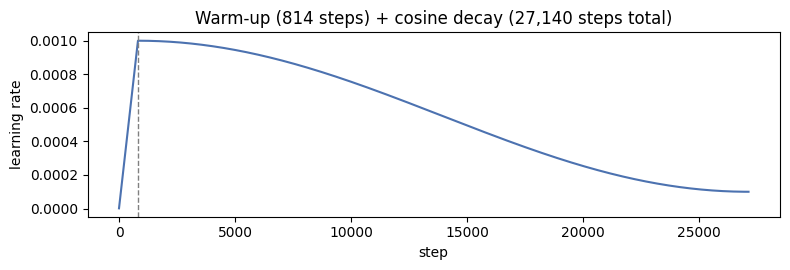

2026-10-05 21:47:47 | INFO    | total_steps=27140 warmup_steps=814


In [25]:
total_steps = cfg.epochs * train_batcher.steps_per_epoch
warmup_steps = max(1, int(cfg.warmup_frac * total_steps))


def lr_at(step):
    if step < warmup_steps:
        return cfg.peak_lr * (step + 1) / warmup_steps
    progress = min(1.0, (step - warmup_steps) / max(1, total_steps - warmup_steps))
    return cfg.min_lr + 0.5 * (cfg.peak_lr - cfg.min_lr) * (1 + math.cos(math.pi * progress))


fig, ax = plt.subplots(figsize=(8, 2.8))
ax.plot([lr_at(s) for s in range(total_steps)], color="#4C72B0")
ax.axvline(warmup_steps, ls="--", c="gray", lw=1)
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
ax.set_title(f"Warm-up ({warmup_steps} steps) + cosine decay ({total_steps:,} steps total)")
plt.tight_layout()
plt.savefig(run_dir / "plots" / "lr_schedule.png", dpi=120)
plt.show()
log.info(f"total_steps={total_steps} warmup_steps={warmup_steps}")

### 3.3 Compile the Model

`torch.compile` fuses the hand-written attention and LayerNorm into far fewer kernels, which typically gives a 1.5–2× speedup. If compilation fails on a particular GPU or driver, the run falls back to eager mode.

In [26]:
model = raw_model
if cfg.compile and device == "cuda":
    try:
        model = torch.compile(raw_model)
        with amp_ctx():
            _, warm_loss = model(xb, yb)
        warm_loss.backward()
        optimizer.zero_grad(set_to_none=True)
        log.info("torch.compile enabled")
    except Exception as err:
        model = raw_model
        optimizer.zero_grad(set_to_none=True)
        log.warning(f"torch.compile failed, using eager mode: {err!r}")

2026-10-05 21:48:14 | INFO    | torch.compile enabled


### 3.4 Evaluation Function

The evaluation function computes token-level cross-entropy, summed over every predicted character, and top-1 next-character accuracy, with dropout turned off. Mid-epoch checks use a fixed random subset of windows so the points are comparable over time. End-of-epoch checks use the full validation set.

In [27]:
@torch.no_grad()
def evaluate(net, data, starts):
    was_training = net.training
    net.eval()
    span = torch.arange(cfg.block_size + 1, device=data.device)
    loss_sum = torch.zeros((), device=device, dtype=torch.float64)
    correct = torch.zeros((), device=device, dtype=torch.int64)
    for i in range(0, len(starts), cfg.batch_size):
        chunk = data[starts[i:i + cfg.batch_size, None] + span].long()
        x, y = chunk[:, :-1], chunk[:, 1:]
        with amp_ctx():
            logits, _ = net(x)
        logits = logits.float()
        loss_sum += F.cross_entropy(logits.view(-1, logits.size(-1)), y.reshape(-1), reduction="sum")
        correct += (logits.argmax(-1) == y).sum()
    net.train(was_training)
    n_tokens = len(starts) * cfg.block_size
    return {"loss": loss_sum.item() / n_tokens, "acc": correct.item() / n_tokens}


val_full = eval_starts(val_data, cfg.block_size, cfg.batch_size)
val_quick = eval_starts(val_data, cfg.block_size, cfg.batch_size, cfg.eval_batches, seed=1)
train_quick = eval_starts(train_data, cfg.block_size, cfg.batch_size, cfg.eval_batches, seed=2)
train_epoch_eval = eval_starts(train_data, cfg.block_size, cfg.batch_size, len(val_full) // cfg.batch_size, seed=3)
print(f"val windows: full={len(val_full):,} quick={len(val_quick):,} | train eval windows/epoch={len(train_epoch_eval):,}")

val windows: full=34,816 quick=5,120 | train eval windows/epoch=34,816


### 3.5 Training Step and Stability Monitor

Each step runs a forward pass under autocast, cross-entropy loss, backward, gradient-norm clipping at 1.0 and an AdamW update. The gradient norm is recorded *before* clipping. A step with a non-finite loss or gradient is skipped and logged. A **loss spike** is a step whose loss exceeds `spike_factor` times the exponential moving average of recent losses (checked only after warm-up).

In [28]:
def train_step(x, y, lr):
    for group in optimizer.param_groups:
        group["lr"] = lr
    with amp_ctx():
        _, loss = model(x, y)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(raw_model.parameters(), cfg.grad_clip)
    loss_v, gn_v = loss.item(), grad_norm.item()
    finite = math.isfinite(loss_v) and math.isfinite(gn_v)
    if finite or scaler.is_enabled():
        scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad(set_to_none=True)
    return loss_v, gn_v, finite

In [29]:
class StabilityMonitor:
    def __init__(self, warmup, factor, beta=0.98):
        self.warmup, self.factor, self.beta = warmup, factor, beta
        self.ema = None
        self.spikes, self.nonfinite = [], []

    def update(self, step, loss, grad_norm, finite):
        if not finite:
            self.nonfinite.append(step)
            log.warning(f"non-finite step={step} loss={loss} grad_norm={grad_norm} (update skipped)")
            return
        if self.ema is not None and step > self.warmup and loss > self.factor * self.ema:
            self.spikes.append({"step": step, "loss": loss, "ema": self.ema})
            log.warning(f"loss spike step={step} loss={loss:.4f} ema={self.ema:.4f}")
        self.ema = loss if self.ema is None else self.beta * self.ema + (1 - self.beta) * loss

### 3.6 Checkpointing

- `ckpt_last.pt`: the full training state (model, optimizer, scaler, vocabulary), overwritten every epoch.
- `ckpt_best.pt`: the same contents, saved whenever the full validation loss improves. All reported metrics come from this checkpoint.
- `epoch_XX.pt`: model weights only for each epoch, so every row of the epoch table can be traced to a file.

In [30]:
def save_checkpoint(path, epoch, step, metrics, full=True):
    state = {
        "model": raw_model.state_dict(),
        "config": asdict(cfg),
        "vocab": {"idx_to_char": idx_to_char, "eos_id": EOS_ID, "unk_id": UNK_ID},
        "epoch": epoch,
        "step": step,
        "metrics": metrics,
        "run_id": run_id,
    }
    if full:
        state["optimizer"] = optimizer.state_dict()
        state["scaler"] = scaler.state_dict()
    torch.save(state, path)


def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while block := f.read(chunk):
            h.update(block)
    return h.hexdigest()

### 3.7 Training Loop

Each epoch is one full pass over the training windows. The loop logs to `train.log` every `log_every` steps, runs a quick train/validation check every `eval_interval` steps, and runs a full validation pass at the end of every epoch. Training throughput is measured on synchronised step times only, excluding evaluation and the first 20 steps, which include compilation.

In [31]:
monitor = StabilityMonitor(warmup_steps, cfg.spike_factor)
steps_log, quick_evals, epoch_rows, checkpoints = [], [], [], []
step_times = []
best_val, global_step = float("inf"), 0
tokens_per_step = cfg.batch_size * cfg.block_size
step_file = open(run_dir / "step_metrics.jsonl", "a")

if device == "cuda":
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
log.info(f"training start: epochs={cfg.epochs} steps={total_steps:,} tokens/step={tokens_per_step:,}")
train_start = time.time()

2026-10-05 21:48:14 | INFO    | training start: epochs=10 steps=27,140 tokens/step=32,768


In [32]:
for epoch in range(1, cfg.epochs + 1):
    epoch_start, epoch_loss, epoch_steps = time.time(), 0.0, 0

    for x, y in train_batcher.epoch():
        lr = lr_at(global_step)
        t0 = time.perf_counter()
        loss_v, gn_v, finite = train_step(x, y, lr)
        step_times.append(time.perf_counter() - t0)
        global_step += 1
        monitor.update(global_step, loss_v, gn_v, finite)
        if finite:
            epoch_loss += loss_v
            epoch_steps += 1

        record = {"step": global_step, "epoch": epoch, "lr": lr, "loss": loss_v, "grad_norm": gn_v}
        steps_log.append(record)
        step_file.write(json.dumps(record) + "\n")

        if global_step % cfg.log_every == 0:
            recent = step_times[-cfg.log_every:]
            log.info(f"ep {epoch:02d} step {global_step:>6}/{total_steps} loss {loss_v:.4f} "
                     f"gnorm {gn_v:.3f} lr {lr:.2e} tok/s {tokens_per_step * len(recent) / sum(recent):,.0f}")
            step_file.flush()

        if global_step % cfg.eval_interval == 0:
            tq, vq = evaluate(model, train_data, train_quick), evaluate(model, val_data, val_quick)
            quick_evals.append({"step": global_step, "train_loss": tq["loss"], "val_loss": vq["loss"]})
            log.info(f"eval step {global_step} train_loss {tq['loss']:.4f} val_loss {vq['loss']:.4f} val_acc {vq['acc']:.4f}")

    val_m = evaluate(model, val_data, val_full)
    train_m = evaluate(model, train_data, train_epoch_eval)
    row = {
        "epoch": epoch, "step": global_step,
        "train_loss_running": epoch_loss / max(1, epoch_steps),
        "train_loss": train_m["loss"], "val_loss": val_m["loss"],
        "gap": val_m["loss"] - train_m["loss"],
        "val_ppl": math.exp(val_m["loss"]), "val_bpc": val_m["loss"] / math.log(2),
        "val_acc": val_m["acc"], "lr": lr, "epoch_time_s": time.time() - epoch_start,
    }
    epoch_rows.append(row)
    log.info("epoch_end " + json.dumps({k: round(v, 5) if isinstance(v, float) else v for k, v in row.items()}))

    if cfg.keep_epoch_weights:
        path = run_dir / "checkpoints" / f"epoch_{epoch:02d}.pt"
        save_checkpoint(path, epoch, global_step, row, full=False)
        checkpoints.append({"file": str(path.relative_to(run_dir)), "epoch": epoch, "step": global_step,
                            "val_loss": row["val_loss"], "train_loss": row["train_loss"], "kind": "epoch weights"})
    save_checkpoint(run_dir / "checkpoints" / "ckpt_last.pt", epoch, global_step, row)
    if row["val_loss"] < best_val:
        best_val, best_epoch = row["val_loss"], epoch
        save_checkpoint(run_dir / "checkpoints" / "ckpt_best.pt", epoch, global_step, row)
        log.info(f"new best val_loss={best_val:.4f} at epoch {epoch} -> ckpt_best.pt")

2026-10-05 21:48:16 | INFO    | ep 01 step     50/27140 loss 2.5661 gnorm 0.938 lr 6.14e-05 tok/s 966,342
2026-10-05 21:48:17 | INFO    | ep 01 step    100/27140 loss 2.3536 gnorm 0.505 lr 1.23e-04 tok/s 1,052,661
2026-10-05 21:48:19 | INFO    | ep 01 step    150/27140 loss 2.2747 gnorm 0.665 lr 1.84e-04 tok/s 1,052,447
2026-10-05 21:48:20 | INFO    | ep 01 step    200/27140 loss 2.2104 gnorm 0.943 lr 2.46e-04 tok/s 1,051,382
2026-10-05 21:48:22 | INFO    | ep 01 step    250/27140 loss 2.0772 gnorm 1.958 lr 3.07e-04 tok/s 1,050,634
2026-10-05 21:48:23 | INFO    | ep 01 step    300/27140 loss 1.9055 gnorm 1.468 lr 3.69e-04 tok/s 1,046,867
2026-10-05 21:48:25 | INFO    | ep 01 step    350/27140 loss 1.6867 gnorm 1.244 lr 4.30e-04 tok/s 1,050,638
2026-10-05 21:48:27 | INFO    | ep 01 step    400/27140 loss 1.5238 gnorm 0.973 lr 4.91e-04 tok/s 1,052,286
2026-10-05 21:48:28 | INFO    | ep 01 step    450/27140 loss 1.4381 gnorm 1.093 lr 5.53e-04 tok/s 1,048,011
2026-10-05 21:48:30 | INFO    

In [33]:
if device == "cuda":
    torch.cuda.synchronize()
total_train_time = time.time() - train_start
step_file.close()

steady = step_times[20:] if len(step_times) > 40 else step_times
train_tok_per_s = tokens_per_step * len(steady) / sum(steady)
peak_mem_gib = torch.cuda.max_memory_allocated() / 2**30 if device == "cuda" else float("nan")
peak_reserved_gib = torch.cuda.max_memory_reserved() / 2**30 if device == "cuda" else float("nan")

steps_df = pd.DataFrame(steps_log)
epochs_df = pd.DataFrame(epoch_rows)
evals_df = pd.DataFrame(quick_evals)
steps_df.to_csv(run_dir / "step_metrics.csv", index=False)
epochs_df.to_csv(run_dir / "epoch_metrics.csv", index=False)
evals_df.to_csv(run_dir / "quick_evals.csv", index=False)

log.info(f"training done: time={total_train_time / 60:.1f} min tok/s={train_tok_per_s:,.0f} "
         f"peak_alloc={peak_mem_gib:.2f} GiB peak_reserved={peak_reserved_gib:.2f} GiB "
         f"best_epoch={best_epoch} best_val={best_val:.4f}")
epochs_df.round(4)

2026-10-05 22:04:12 | INFO    | training done: time=16.0 min tok/s=1,041,747 peak_alloc=4.61 GiB peak_reserved=4.67 GiB best_epoch=10 best_val=0.5438


,epoch,step,train_loss_running,train_loss,val_loss,gap,val_ppl,val_bpc,val_acc,lr,epoch_time_s
0,1,2714,1.0757,0.6950,0.6965,0.0015,2.0067,1.0048,0.7808,0.0010,101.1013
1,2,5428,0.6923,0.6383,0.6419,0.0036,1.9000,0.9260,0.7972,0.0009,94.5066
2,3,8142,0.6521,0.6080,0.6159,0.0079,1.8513,0.8885,0.8053,0.0008,94.9772
3,4,10856,0.6290,0.5899,0.5977,0.0078,1.8179,0.8622,0.8105,0.0007,94.2997
4,5,13570,0.6117,0.5744,0.5838,0.0094,1.7929,0.8423,0.8146,0.0006,94.7096
5,6,16284,0.5962,0.5610,0.5721,0.0112,1.7721,0.8254,0.8182,0.0004,93.9543
6,7,18998,0.5837,0.5487,0.5611,0.0124,1.7526,0.8095,0.8216,0.0003,94.3748
7,8,21712,0.5715,0.5382,0.5528,0.0146,1.7381,0.7975,0.8242,0.0002,95.1098
8,9,24426,0.5634,0.5315,0.5465,0.0149,1.7271,0.7884,0.8261,0.0001,94.4543
9,10,27140,0.5569,0.5279,0.5438,0.0160,1.7226,0.7846,0.8268,0.0001,95.1343


## 4. Loss Curves

### 4.1 Training and Validation Loss

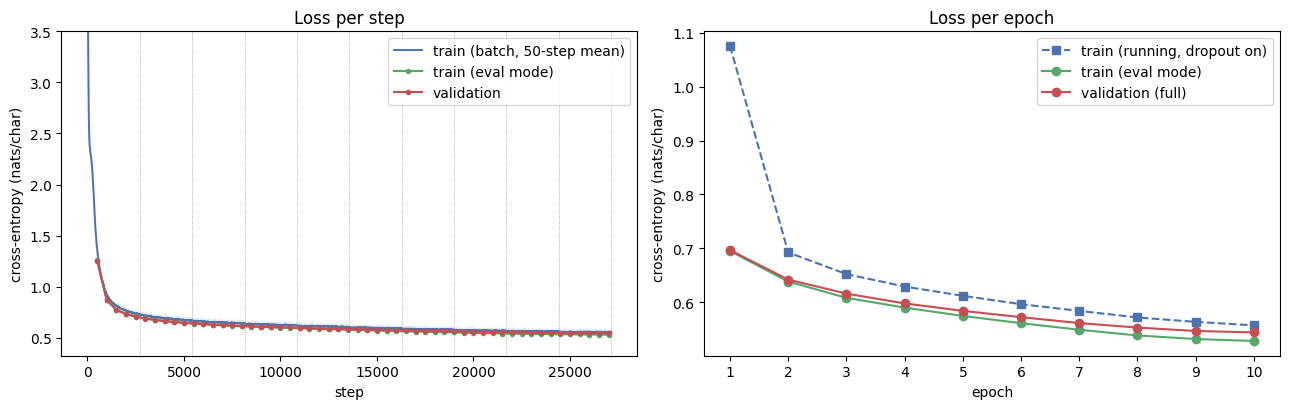

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
smooth = steps_df["loss"].rolling(50, min_periods=1).mean()
ax.plot(steps_df["step"], steps_df["loss"], color="#4C72B0", alpha=0.15, lw=0.6)
ax.plot(steps_df["step"], smooth, color="#4C72B0", lw=1.4, label="train (batch, 50-step mean)")
if len(evals_df):
    ax.plot(evals_df["step"], evals_df["train_loss"], "o-", ms=3, color="#55A868", label="train (eval mode)")
    ax.plot(evals_df["step"], evals_df["val_loss"], "o-", ms=3, color="#C44E52", label="validation")
for s in epochs_df["step"]:
    ax.axvline(s, color="gray", lw=0.5, ls=":")
ax.set_ylim(top=min(3.5, steps_df["loss"].max()))
ax.set_xlabel("step")
ax.set_ylabel("cross-entropy (nats/char)")
ax.set_title("Loss per step")
ax.legend()

ax = axes[1]
ax.plot(epochs_df["epoch"], epochs_df["train_loss_running"], "s--", color="#4C72B0", label="train (running, dropout on)")
ax.plot(epochs_df["epoch"], epochs_df["train_loss"], "o-", color="#55A868", label="train (eval mode)")
ax.plot(epochs_df["epoch"], epochs_df["val_loss"], "o-", color="#C44E52", label="validation (full)")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy (nats/char)")
ax.set_title("Loss per epoch")
ax.set_xticks(epochs_df["epoch"])
ax.legend()

plt.tight_layout()
plt.savefig(run_dir / "plots" / "loss_curves.png", dpi=130)
plt.show()

### 4.2 Gradient Norm and Training Stability

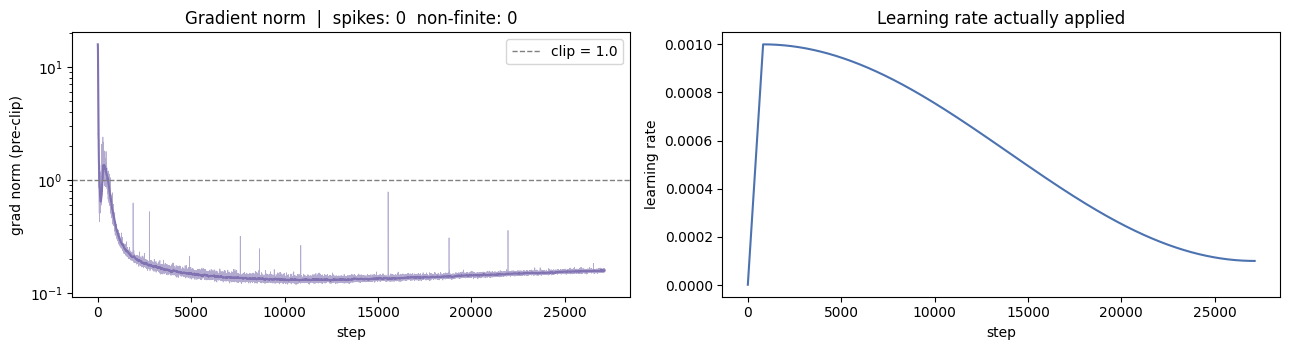

2026-10-05 22:04:15 | INFO    | stability {"grad_norm_mean": 0.1501926994137282, "grad_norm_median": 0.1428176686167717, "grad_norm_p99": 0.3178843930363655, "grad_norm_max": 15.820178031921387, "clipped_step_frac": 0.01234340456890199, "loss_spikes": 0, "nonfinite_steps": 0}


{'grad_norm_mean': 0.1501926994137282,
 'grad_norm_median': 0.1428176686167717,
 'grad_norm_p99': 0.3178843930363655,
 'grad_norm_max': 15.820178031921387,
 'clipped_step_frac': 0.01234340456890199,
 'loss_spikes': 0,
 'nonfinite_steps': 0}

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))

ax = axes[0]
ax.plot(steps_df["step"], steps_df["grad_norm"], color="#8172B2", lw=0.5, alpha=0.6)
ax.plot(steps_df["step"], steps_df["grad_norm"].rolling(100, min_periods=1).median(), color="#8172B2", lw=1.5)
ax.axhline(cfg.grad_clip, color="gray", ls="--", lw=1, label=f"clip = {cfg.grad_clip}")
for sp in monitor.spikes:
    ax.axvline(sp["step"], color="#C44E52", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("grad norm (pre-clip)")
ax.set_title(f"Gradient norm  |  spikes: {len(monitor.spikes)}  non-finite: {len(monitor.nonfinite)}")
ax.legend()

ax = axes[1]
ax.plot(steps_df["step"], steps_df["lr"], color="#4C72B0")
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
ax.set_title("Learning rate actually applied")

plt.tight_layout()
plt.savefig(run_dir / "plots" / "stability.png", dpi=130)
plt.show()

post_warm = steps_df[steps_df["step"] > warmup_steps]
stability = {
    "grad_norm_mean": float(post_warm["grad_norm"].mean()),
    "grad_norm_median": float(post_warm["grad_norm"].median()),
    "grad_norm_p99": float(post_warm["grad_norm"].quantile(0.99)),
    "grad_norm_max": float(steps_df["grad_norm"].max()),
    "clipped_step_frac": float((steps_df["grad_norm"] > cfg.grad_clip).mean()),
    "loss_spikes": len(monitor.spikes),
    "nonfinite_steps": len(monitor.nonfinite),
}
log.info("stability " + json.dumps(stability))
stability

## 5. Text Generation

### 5.1 Decoding

Generation is autoregressive. The prompt is prefixed with `<|eos|>` so the model knows a new story is starting. At each step the last `block_size` characters go through the model, and the next character is picked in one of two ways:

- **Greedy** (`temperature = 0`): the argmax.
- **Temperature sampling**: sample from $\mathrm{softmax}(z / \tau)$, with optional top-k truncation.

`<unk>` is never sampled. Generation stops at `<|eos|>` or at `max_new_tokens`.

In [36]:
@torch.no_grad()
def generate(net, prompts, max_new_tokens=600, temperature=0.8, top_k=None, stop_at_eos=True):
    net.eval()
    encoded = [[EOS_ID] + encode(p) for p in prompts]
    assert len({len(e) for e in encoded}) == 1, "batched prompts must have equal length"
    idx = torch.tensor(encoded, device=device)
    done = torch.zeros(len(prompts), dtype=torch.bool, device=device)
    for _ in range(max_new_tokens):
        with amp_ctx():
            logits, _ = net(idx[:, -cfg.block_size:])
        logits = logits[:, -1, :].float()
        logits[:, UNK_ID] = float("-inf")
        if temperature == 0:
            nxt = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k is not None:
                kth = torch.topk(logits, top_k).values[:, [-1]]
                logits = logits.masked_fill(logits < kth, float("-inf"))
            nxt = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)
        idx = torch.cat([idx, nxt], dim=1)
        if stop_at_eos:
            done |= nxt.squeeze(1) == EOS_ID
            if done.all():
                break
    texts = []
    for row, prompt in zip(idx.tolist(), prompts):
        gen = row[len(encoded[0]):]
        if stop_at_eos and EOS_ID in gen:
            gen = gen[:gen.index(EOS_ID)]
        texts.append(prompt + decode(gen))
    return texts

### 5.2 Load the Best Checkpoint

In [37]:
best_ckpt = torch.load(run_dir / "checkpoints" / "ckpt_best.pt", map_location=device)
raw_model.load_state_dict(best_ckpt["model"])
raw_model.eval()
log.info(f"loaded ckpt_best.pt (epoch {best_ckpt['epoch']}, step {best_ckpt['step']}, "
         f"val_loss {best_ckpt['metrics']['val_loss']:.4f})")

2026-10-05 22:04:15 | INFO    | loaded ckpt_best.pt (epoch 10, step 27140, val_loss 0.5438)


### 5.3 Greedy vs. Temperature Sampling

In [38]:
PROMPTS = [
    "Once upon a time",
    "One day, a little girl named Lily",
    "Tom and his dog went to the park.",
    "The sun was hot and the bird",
]
SETTINGS = [("greedy", 0.0, None), ("t=0.5", 0.5, None), ("t=0.8", 0.8, None), ("t=1.0, top-k 20", 1.0, 20), ("t=1.3", 1.3, None)]

set_seed(cfg.seed)
showcase = []
for prompt in PROMPTS:
    for name, temp, k in SETTINGS:
        text = generate(raw_model, [prompt], max_new_tokens=500, temperature=temp, top_k=k)[0]
        showcase.append({"prompt": prompt, "setting": name, "temperature": temp, "top_k": k, "text": text})

with open(run_dir / "samples" / "showcase.txt", "w") as f:
    for s in showcase:
        f.write(f"### prompt={s['prompt']!r} setting={s['setting']}\n{s['text']}\n\n")

for s in showcase[: len(SETTINGS)]:
    print(f"── {s['setting']} " + "─" * 60)
    print(s["text"], "\n")

── greedy ────────────────────────────────────────────────────────────
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big bug on the ground. She picked it up and showed it to her mom."Look, Mommy! I found a bug!" she said.Her mom smiled and said, "That's a great idea, Lily. Let's go and see what we can find." They went to the bug and saw a big bug on its leg. It was so big and strong that it could fly around it. Lily was so happy and said, "Thank you, Mommy!" They both smiled and went back to playing in the garde 

── t=0.5 ────────────────────────────────────────────────────────────
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big red ball in the sky. She wanted to play with it, but she didn't know how. She asked her mom for help but her mom came in and saw her struggling. "Lily, it's time to go home now," her mom said. "It's time for a nap." Lily

In [39]:
for s in showcase[len(SETTINGS):]:
    if s["setting"] in ("greedy", "t=0.8"):
        print(f"── {s['setting']} | {s['prompt']!r} " + "─" * 30)
        print(s["text"], "\n")

── greedy | 'One day, a little girl named Lily' ──────────────────────────────
One day, a little girl named Lily went to the park with her mom. They saw a big tree with a lot of leaves. Lily wanted to climb the tree and see the leaves. She asked her mom if she could climb the tree. Her mom said yes, but only if Lily climbed the tree. Lily was very happy and said yes. She climbed the tree and sat on the branch. She climbed the tree and sat on the branch. She saw a big branch with a long tail and a big brown eye. She said to her mom, "Mom, look at the branch! It is so big and strong!"Her mom smiled and said 

── t=0.8 | 'One day, a little girl named Lily' ──────────────────────────────
One day, a little girl named Lily went to the park with her mom. She saw a big slide and wanted to go down it. Her mom said, "Can you please go down the slide?" Lily replied, "Of course, I can!" So, her mom went down the slide and got ready.As they were playing, Lily said, "Mommy, I don't like the slide an

### 5.4 Generation Throughput

Two figures are measured. **Single-stream** speed is how fast one story is written (latency-bound). **Batched** speed is 32 stories generated in parallel (throughput-bound). The generator has no KV-cache, so it recomputes the whole context window at every step; these numbers are a conservative lower bound.

In [40]:
def time_generation(batch, n_tokens=400):
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    generate(raw_model, ["Once upon a time"] * batch, max_new_tokens=n_tokens, temperature=1.0, stop_at_eos=False)
    if device == "cuda":
        torch.cuda.synchronize()
    return batch * n_tokens / (time.perf_counter() - t0)


time_generation(1, 20)
gen_tok_per_s_single = time_generation(1)
gen_tok_per_s_batched = time_generation(32)
log.info(f"generation tok/s single={gen_tok_per_s_single:,.0f} batched32={gen_tok_per_s_batched:,.0f}")
print(f"single stream: {gen_tok_per_s_single:,.0f} chars/s   batched x32: {gen_tok_per_s_batched:,.0f} chars/s")

2026-10-05 22:05:39 | INFO    | generation tok/s single=127 batched32=3,767
single stream: 127 chars/s   batched x32: 3,767 chars/s


## 6. Evaluation Metrics

### 6.1 Loss-Based Metrics on the Best Checkpoint

These are computed with dropout off, over the **full** validation set and the training set (all of it unless `final_train_eval_batches` is set).

- Perplexity = $e^{\mathrm{CE}}$
- Bits-per-character = $\mathrm{CE} / \ln 2$
- Generalization gap = val CE − train CE

In [41]:
final_train_starts = eval_starts(train_data, cfg.block_size, cfg.batch_size, cfg.final_train_eval_batches, seed=4)
final_train = evaluate(model, train_data, final_train_starts)
final_val = evaluate(model, val_data, val_full)

loss_metrics = {
    "train_ce": final_train["loss"],
    "val_ce": final_val["loss"],
    "train_ppl": math.exp(final_train["loss"]),
    "val_ppl": math.exp(final_val["loss"]),
    "train_bpc": final_train["loss"] / math.log(2),
    "val_bpc": final_val["loss"] / math.log(2),
    "gen_gap": final_val["loss"] - final_train["loss"],
    "gen_gap_ratio": final_val["loss"] / final_train["loss"],
    "train_top1": final_train["acc"],
    "val_top1": final_val["acc"],
}
log.info("final_metrics " + json.dumps(loss_metrics))
pd.Series(loss_metrics).round(4).to_frame("best checkpoint")

2026-10-05 22:06:05 | INFO    | final_metrics {"train_ce": 0.5274205633117244, "val_ce": 0.5438411579850841, "train_ppl": 1.694555667351993, "val_ppl": 1.7226109912775516, "train_bpc": 0.7609070311526883, "val_bpc": 0.7845969416563922, "gen_gap": 0.016420594673359767, "gen_gap_ratio": 1.031133777891126, "train_top1": 0.8310982711893192, "val_top1": 0.8268413543701172}


,best checkpoint
train_ce,0.5274
val_ce,0.5438
train_ppl,1.6946
val_ppl,1.7226
train_bpc,0.7609
val_bpc,0.7846
gen_gap,0.0164
gen_gap_ratio,1.0311
train_top1,0.8311
val_top1,0.8268


### 6.2 Generation Diversity and Repetition

Diversity is measured on 64 stories sampled from scratch, each starting from `<|eos|>` alone, at the main setting τ = 0.8. As a reference, the same metrics are computed on 64 real validation stories.

- **Distinct-n**: unique word n-grams ÷ total word n-grams, pooled over all samples (Li et al., 2016). Words are lower-cased alphabetic tokens.
- **Repeated 4-gram rate**: within each sample, the share of word 4-grams that already occurred earlier in that sample, averaged over samples. A value near 0 means no copying loops.
- **Invented-word rate**: the share of generated words that never appear in the training set. This is specific to a character-level model, which can spell words that don't exist.

In [42]:
WORD_RE = re.compile(r"[A-Za-z']+")


def words(text):
    return [w.lower() for w in WORD_RE.findall(text)]


def ngrams(tokens, n):
    return list(zip(*(tokens[i:] for i in range(n))))


def distinct_n(texts, n):
    grams = [g for t in texts for g in ngrams(words(t), n)]
    return len(set(grams)) / max(1, len(grams))


def repeated_ngram_rate(text, n=4):
    grams = ngrams(words(text), n)
    return 1 - len(set(grams)) / len(grams) if grams else 0.0


train_vocab_words = set(words(train_text))


def invented_words(text):
    return [w for w in words(text) if w.strip("'") and w not in train_vocab_words]


def diversity_report(texts):
    total_words = sum(len(words(t)) for t in texts)
    return {
        "distinct_1": distinct_n(texts, 1),
        "distinct_2": distinct_n(texts, 2),
        "distinct_3": distinct_n(texts, 3),
        "rep_4gram": float(np.mean([repeated_ngram_rate(t) for t in texts])),
        "invented_word_rate": sum(len(invented_words(t)) for t in texts) / max(1, total_words),
        "mean_chars": float(np.mean([len(t) for t in texts])),
    }

In [43]:
set_seed(cfg.seed + 1)
main_samples = []
for _ in range(4):
    main_samples += generate(raw_model, [""] * 16, max_new_tokens=800, temperature=0.8)

set_seed(cfg.seed + 2)
greedy_samples = [generate(raw_model, [p], max_new_tokens=600, temperature=0.0)[0] for p in PROMPTS]

reference = val_stories[:64]
diversity = {
    "model (t=0.8)": diversity_report(main_samples),
    "model (greedy)": diversity_report(greedy_samples),
    "real val stories": diversity_report(reference),
}
with open(run_dir / "samples" / "unconditional_t0.8.txt", "w") as f:
    f.write("\n\n<|eos|>\n\n".join(main_samples))
log.info("diversity " + json.dumps(diversity))
pd.DataFrame(diversity).round(4)

2026-10-05 22:06:57 | INFO    | diversity {"model (t=0.8)": {"distinct_1": 0.11016850668216153, "distinct_2": 0.48319868867814075, "distinct_3": 0.7572254335260116, "rep_4gram": 0.010768178540635262, "invented_word_rate": 0.0013945380592678676, "mean_chars": 666.140625}, "model (greedy)": {"distinct_1": 0.23340040241448692, "distinct_2": 0.4949290060851927, "distinct_3": 0.621676891615542, "rep_4gram": 0.27676906261418366, "invented_word_rate": 0.002012072434607646, "mean_chars": 603.0}, "real val stories": {"distinct_1": 0.12270842929525565, "distinct_2": 0.5840051895097766, "distinct_3": 0.8672508623100588, "rep_4gram": 0.010907823506986302, "invented_word_rate": 0.0008291110087517273, "mean_chars": 855.953125}}


,model (t=0.8),model (greedy),real val stories
distinct_1,0.1102,0.2334,0.1227
distinct_2,0.4832,0.4949,0.5840
distinct_3,0.7572,0.6217,0.8673
rep_4gram,0.0108,0.2768,0.0109
invented_word_rate,0.0014,0.0020,0.0008
mean_chars,666.1406,603.0000,855.9531


### 6.3 Metrics Report (`metrics.md`)

All Task 1 metrics go into one markdown report next to the raw log, and the same values are written to `metrics.json`.

In [44]:
def md_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "|" + "---|" * len(headers)]
    lines += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    return "\n".join(lines)


model_div = diversity["model (t=0.8)"]
ref_div = diversity["real val stories"]

summary_rows = [
    ("Training cross-entropy loss (nats/char)", f"{loss_metrics['train_ce']:.4f}"),
    ("Validation cross-entropy loss (nats/char)", f"{loss_metrics['val_ce']:.4f}"),
    ("Validation perplexity", f"{loss_metrics['val_ppl']:.4f}"),
    ("Training perplexity", f"{loss_metrics['train_ppl']:.4f}"),
    ("Validation bits-per-character", f"{loss_metrics['val_bpc']:.4f}"),
    ("Training bits-per-character", f"{loss_metrics['train_bpc']:.4f}"),
    ("Generalization gap (val − train CE)", f"{loss_metrics['gen_gap']:+.4f} ({(loss_metrics['gen_gap_ratio'] - 1) * 100:+.2f}%)"),
    ("Top-1 next-character accuracy (val)", f"{loss_metrics['val_top1'] * 100:.2f}%"),
    ("Top-1 next-character accuracy (train)", f"{loss_metrics['train_top1'] * 100:.2f}%"),
    ("Distinct-1 / 2 / 3 (t=0.8)", f"{model_div['distinct_1']:.4f} / {model_div['distinct_2']:.4f} / {model_div['distinct_3']:.4f}"),
    ("Repeated 4-gram rate (t=0.8)", f"{model_div['rep_4gram'] * 100:.2f}%"),
    ("Invented-word rate (t=0.8)", f"{model_div['invented_word_rate'] * 100:.2f}%"),
    ("Gradient norm, post-warm-up (mean / median / p99 / max)",
     f"{stability['grad_norm_mean']:.3f} / {stability['grad_norm_median']:.3f} / {stability['grad_norm_p99']:.3f} / {stability['grad_norm_max']:.3f}"),
    ("Steps clipped (grad norm > clip)", f"{stability['clipped_step_frac'] * 100:.2f}%"),
    ("Loss spikes / NaN-Inf steps", f"{stability['loss_spikes']} / {stability['nonfinite_steps']}"),
    ("Parameter count (total / non-embedding)", f"{n_params:,} / {n_params - n_embed_params:,}"),
    ("Training throughput (tokens/sec)", f"{train_tok_per_s:,.0f}"),
    ("Generation throughput, single / batch-32 (tokens/sec)", f"{gen_tok_per_s_single:,.0f} / {gen_tok_per_s_batched:,.0f}"),
    ("Peak GPU memory (allocated / reserved)", f"{peak_mem_gib:.2f} GiB / {peak_reserved_gib:.2f} GiB"),
    ("Total training time (incl. evals)", f"{total_train_time / 60:.1f} min"),
]

In [45]:
epoch_table = md_table(
    ["epoch", "step", "train CE (running)", "train CE", "val CE", "gap", "val PPL", "val BPC", "val top-1", "checkpoint"],
    [(int(r.epoch), int(r.step), f"{r.train_loss_running:.4f}", f"{r.train_loss:.4f}", f"{r.val_loss:.4f}",
      f"{r.gap:+.4f}", f"{r.val_ppl:.3f}", f"{r.val_bpc:.4f}", f"{r.val_acc * 100:.2f}%",
      f"epoch_{int(r.epoch):02d}.pt" + (" + ckpt_best.pt" if int(r.epoch) == best_epoch else ""))
     for r in epochs_df.itertuples()],
)
div_table = md_table(
    ["source", "distinct-1", "distinct-2", "distinct-3", "rep. 4-gram", "invented words", "mean chars"],
    [(k, f"{v['distinct_1']:.4f}", f"{v['distinct_2']:.4f}", f"{v['distinct_3']:.4f}",
      f"{v['rep_4gram'] * 100:.2f}%", f"{v['invented_word_rate'] * 100:.2f}%", f"{v['mean_chars']:.0f}")
     for k, v in diversity.items()],
)

report = f"""# Metrics — {run_id}

All numbers come from `checkpoints/ckpt_best.pt` (epoch {best_ckpt['epoch']}, step {best_ckpt['step']}) unless marked per-epoch.
Raw evidence: `train.log`, `step_metrics.jsonl`. Manifest: `manifest.json`.

**Model:** {cfg.n_layer} layers × {cfg.n_head} heads × {cfg.n_embd} dims, context {cfg.block_size} chars, vocab {vocab_size}
**Data:** {cfg.n_train_stories:,} train / {cfg.n_val_stories:,} val stories (seed {cfg.seed}), {data_stats['train_chars']:,} / {data_stats['val_chars']:,} chars
**Training:** {cfg.epochs} epochs, {total_steps:,} steps, {tokens_per_step:,} tokens/step, AdamW peak lr {cfg.peak_lr}, warm-up {warmup_steps} steps + cosine to {cfg.min_lr}
**Hardware:** {env_info['gpu'] or 'CPU'}, torch {env_info['torch']}, amp {env_info['amp_dtype']}

## Task 1 metrics

{md_table(["metric", "value"], summary_rows)}

## Per-epoch results

{epoch_table}

## Generation diversity (64 samples each)

{div_table}

## Plots

- `plots/loss_curves.png`, `plots/stability.png`, `plots/lr_schedule.png`, `plots/story_lengths.png`
"""
(run_dir / "metrics.md").write_text(report)
(run_dir / "metrics.json").write_text(json.dumps({
    "loss": loss_metrics, "diversity": diversity, "stability": stability,
    "spikes": monitor.spikes, "nonfinite_steps": monitor.nonfinite,
    "params_total": n_params, "params_non_embedding": n_params - n_embed_params,
    "train_tokens_per_s": train_tok_per_s, "gen_tokens_per_s_single": gen_tok_per_s_single,
    "gen_tokens_per_s_batch32": gen_tok_per_s_batched, "peak_mem_alloc_gib": peak_mem_gib,
    "peak_mem_reserved_gib": peak_reserved_gib, "total_train_time_s": total_train_time,
    "epochs": epoch_rows,
}, indent=2))
log.info(f"wrote {run_dir / 'metrics.md'}")
print(report)

2026-10-05 22:06:57 | INFO    | wrote runs/20261005-214655_L6H6C384T256/metrics.md
# Metrics — 20261005-214655_L6H6C384T256

All numbers come from `checkpoints/ckpt_best.pt` (epoch 10, step 27140) unless marked per-epoch.
Raw evidence: `train.log`, `step_metrics.jsonl`. Manifest: `manifest.json`.

**Model:** 6 layers × 6 heads × 384 dims, context 256 chars, vocab 83
**Data:** 100,000 train / 10,000 val stories (seed 1337), 88,938,739 / 8,919,002 chars
**Training:** 10 epochs, 27,140 steps, 32,768 tokens/step, AdamW peak lr 0.001, warm-up 814 steps + cosine to 0.0001
**Hardware:** NVIDIA A100-SXM4-80GB, torch 2.11.0+cu130, amp torch.bfloat16

## Task 1 metrics

| metric | value |
|---|---|
| Training cross-entropy loss (nats/char) | 0.5274 |
| Validation cross-entropy loss (nats/char) | 0.5438 |
| Validation perplexity | 1.7226 |
| Training perplexity | 1.6946 |
| Validation bits-per-character | 0.7846 |
| Training bits-per-character | 0.7609 |
| Generalization gap (val − train CE) | +0

## 7. Sequence Model Failure Analysis

### 7.1 Finding Failure Cases

Each failure type is located with a measurable criterion, so the cases are not cherry-picked by eye:

| Failure type | Where it is searched | Selection criterion |
|---|---|---|
| Repetition / looping | greedy samples | highest repeated 4-gram rate |
| Broken words / grammar | high-temperature samples (τ = 1.3) | most words absent from the training vocabulary |
| Loss of coherence / entity drift | long samples (≥ 2 × context window) | lowest content-word overlap between the first and second half, plus character names that appear only in the second half |

In [46]:
STOP = set("""a an the and or but so then to of in on at for with he she it they them his her its their was were
is are be been i you we me my your our said says had has have did do does not no yes very too that this
there here what who when where why how one day up down out into from all as by""".split())


def sentence_names(text):
    names = []
    for sent in re.split(r"(?<=[.!?\"])\s+|\n+", text):
        toks = WORD_RE.findall(sent)
        names += [t for t in toks[1:] if t[0].isupper() and t not in ("I",) and t.lower() not in STOP]
    return names


def half_overlap(text):
    w = [x for x in words(text) if x not in STOP]
    a, b = set(w[: len(w) // 2]), set(w[len(w) // 2:])
    return len(a & b) / max(1, len(a | b))


def window_around_repeat(text, n=4, width=320):
    seen, ws = {}, list(WORD_RE.finditer(text))
    for i in range(len(ws) - n + 1):
        key = tuple(m.group().lower() for m in ws[i:i + n])
        if key in seen:
            start = ws[seen[key]].start()
            return text[max(0, start - 40): start - 40 + width]
        seen[key] = i
    return text[:width]

In [47]:
set_seed(cfg.seed + 3)
greedy_pool = [generate(raw_model, [p], max_new_tokens=700, temperature=0.0)[0] for p in PROMPTS]
hot_pool = []
for p in PROMPTS:
    hot_pool += generate(raw_model, [p] * 4, max_new_tokens=500, temperature=1.3)
long_pool = []
for p in PROMPTS:
    long_pool += generate(raw_model, [p] * 4, max_new_tokens=1500, temperature=0.8)
long_pool = [t for t in long_pool if len(t) >= 2 * cfg.block_size] or long_pool

rep_text = max(greedy_pool, key=repeated_ngram_rate)
broken_text = max(hot_pool, key=lambda t: len(invented_words(t)) / max(1, len(words(t))))
drift_text = min(long_pool, key=half_overlap)

half = len(drift_text) // 2
early_names, late_names = set(sentence_names(drift_text[:half])), set(sentence_names(drift_text[half:]))

In [48]:
failure_cases = [
    {
        "type": "Repetition (degenerate looping)",
        "setting": "greedy decoding (temperature = 0)",
        "snippet": window_around_repeat(rep_text),
        "evidence": f"repeated 4-gram rate {repeated_ngram_rate(rep_text) * 100:.1f}% vs "
                    f"{ref_div['rep_4gram'] * 100:.1f}% in real stories; distinct-2 of greedy set "
                    f"{diversity['model (greedy)']['distinct_2']:.3f} vs {model_div['distinct_2']:.3f} at t=0.8",
        "observation": "Greedy decoding always takes the single most likely character, so once a high-probability "
                       "phrase is produced the same context recurs and the model falls into a loop it cannot "
                       "leave. The looped phrases are usually grammatical, high-frequency TinyStories phrases, so the "
                       "failure is in the decoding strategy, not the per-step predictions.",
    },
    {
        "type": "Broken grammar / invented words",
        "setting": "temperature = 1.3",
        "snippet": broken_text[:360],
        "evidence": f"invented words: {sorted(set(invented_words(broken_text)))[:12]}; invented-word rate "
                    f"{len(invented_words(broken_text)) / max(1, len(words(broken_text))) * 100:.1f}% vs "
                    f"{model_div['invented_word_rate'] * 100:.2f}% at t=0.8",
        "observation": "At high temperature, probability mass moves into the tail, where low-likelihood characters "
                       "are sampled in the middle of words. Because the model spells character by character, one "
                       "bad sample produces a non-word, and each error makes the context less familiar, so errors "
                       "compound. Sentence boundaries and agreement also break down (missing verbs, wrong pronouns).",
    },
    {
        "type": "Loss of coherence / entity drift",
        "setting": f"temperature = 0.8, {len(drift_text)} chars (context window = {cfg.block_size})",
        "snippet": drift_text if len(drift_text) <= 520 else drift_text[:240] + "\n[...]\n" + drift_text[-260:],
        "evidence": f"content-word overlap between halves {half_overlap(drift_text):.3f}; names in first half "
                    f"{sorted(early_names)}, only in second half {sorted(late_names - early_names)}",
        "observation": f"Each sentence is locally fluent, but the story loses its thread. The model only sees the "
                       f"last {cfg.block_size} characters (about {cfg.block_size // 5} words), so after a few sentences the opening "
                       f"(who the protagonist is, what problem was set up) has dropped out of the context. "
                       f"Characters get renamed or replaced and the ending does not resolve the beginning. This "
                       f"is a hard limit of the context window, not under-training.",
    },
]

lines = [f"# Failure analysis — {run_id}\n", f"Checkpoint: `ckpt_best.pt` (epoch {best_ckpt['epoch']})\n"]
for i, case in enumerate(failure_cases, 1):
    lines += [f"## Case {i}: {case['type']}", f"**Setting:** {case['setting']}  ",
              f"**Evidence:** {case['evidence']}\n", "```text", case["snippet"].strip(), "```",
              f"**Observation:** {case['observation']}\n"]
(run_dir / "failure_analysis.md").write_text("\n".join(lines))

for i, case in enumerate(failure_cases, 1):
    print(f"═══ Case {i}: {case['type']}  [{case['setting']}]")
    print(case["snippet"].strip())
    print(f"\n→ evidence: {case['evidence']}\n")

═══ Case 1: Repetition (degenerate looping)  [greedy decoding (temperature = 0)]
The sun was hot and the birds were singing. The birds were singing and the sky was blue. The birds were singing and the sun was shining. The birds were singing and the sky was blue. The birds were singing and the sun was shining. The birds were singing and the sun was shining. The birds were singing

→ evidence: repeated 4-gram rate 82.4% vs 1.1% in real stories; distinct-2 of greedy set 0.495 vs 0.483 at t=0.8

═══ Case 2: Broken grammar / invented words  [temperature = 1.3]
The sun was hot and the birds below. Billy and Marter Johnny had to eat more and more.Two, one of them, Sarah,â€ in Sarah.â€œDid you either, ; over Thie classroom?â€ he said, shakiing his head.Sarah stared at the lake.â€œOh no,â€ then asked ignorant. â€œIt didnâ€TMt belong to me.â€To's poor voice smiled and , just listening very loud!â€Something amazing caug

→ evidence: invented words: ['marter', 'shakiing', 'thie', "to's"]; invented

### 7.2 Discussion

**Case 1 — Repetition.** Greedy decoding turns a well-calibrated model into a degenerate one. The model's distribution is not wrong: real TinyStories do reuse a small set of phrases, and in a loop each next character really is the most likely one given the loop so far. With no randomness, nothing breaks the cycle. Temperature sampling (τ ≈ 0.8) removes nearly all loops, which shows up in the much lower repeated 4-gram rate in §6.2. Repetition penalties or nucleus sampling would also help.

**Case 2 — Broken words and grammar.** This failure is specific to character-level models. A subword model can only emit real vocabulary items, but a character model has to *spell*, and every character is a chance to leave the space of real words. At τ = 1.3 the flattened distribution makes such errors common, and each mistake lowers the quality of the context for the steps that follow, the usual exposure-bias compounding. At τ ≤ 0.8 the invented-word rate stays low, which shows the model has learned spelling; the problem is sampling from its long tail.

**Case 3 — Loss of coherence.** A 256-character window is roughly 2–3 sentences. TinyStories average about 800 characters, so by the end of a story the model can no longer see its beginning. It keeps local fluency (grammar, punctuation, dialogue quotes) but loses global state: who the characters are, what the conflict was, and whether it has been resolved. The validation loss can't show this failure well, because most next-character predictions only need local context. A longer `block_size`, subword tokenisation (more text per position) or a larger model would each extend the usable story context.

## 8. Run Manifest

The manifest links each checkpoint file to the results it produced, together with the environment, data split and configuration.

In [49]:
best_path = run_dir / "checkpoints" / "ckpt_best.pt"
last_path = run_dir / "checkpoints" / "ckpt_last.pt"
ckpt_entries = [
    {"file": str(best_path.relative_to(run_dir)), "epoch": best_ckpt["epoch"], "step": best_ckpt["step"],
     "val_loss": best_ckpt["metrics"]["val_loss"], "kind": "full state (best val)",
     "used_for": "all metrics in metrics.md, all generated samples, failure_analysis.md"},
    {"file": str(last_path.relative_to(run_dir)), "epoch": epoch_rows[-1]["epoch"], "step": epoch_rows[-1]["step"],
     "val_loss": epoch_rows[-1]["val_loss"], "kind": "full state (last epoch)", "used_for": "resuming training"},
] + [dict(c, used_for=f"per-epoch row {c['epoch']} in metrics.md") for c in checkpoints]
for entry in ckpt_entries:
    entry["sha256"] = sha256(run_dir / entry["file"])

manifest = {
    "run_id": run_id,
    "finished": datetime.now().isoformat(timespec="seconds"),
    "notebook": "gpt_tinystories_char.ipynb",
    "environment": env_info,
    "environment_file": "requirements-lock.txt",
    "dataset": {
        "name": cfg.dataset_name, "source_split": "train", "split_seed": cfg.seed,
        "n_train_stories": len(train_stories), "n_val_stories": len(val_stories),
        "split_indices_file": "split_indices.json", "vocab_file": "vocab.json",
        "vocab_size": vocab_size, **data_stats,
    },
    "config": asdict(cfg),
    "model": {"params_total": n_params, "params_non_embedding": n_params - n_embed_params},
    "checkpoints": ckpt_entries,
    "artifacts": {
        "raw_log": "train.log", "step_metrics": ["step_metrics.jsonl", "step_metrics.csv"],
        "epoch_metrics": "epoch_metrics.csv", "quick_evals": "quick_evals.csv",
        "metrics_report": "metrics.md", "metrics_json": "metrics.json",
        "failure_analysis": "failure_analysis.md", "samples": "samples/", "plots": "plots/",
    },
}
(run_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))

manifest_md = [f"# Manifest — {run_id}\n", "## Environment\n",
               md_table(["item", "value"], [(k, v) for k, v in env_info.items()]),
               "\nFull package list: `requirements-lock.txt`\n", "## Checkpoint → result mapping\n",
               md_table(["file", "epoch", "step", "val CE", "used for", "sha256"],
                        [(e["file"], e["epoch"], e["step"], f"{e['val_loss']:.4f}", e["used_for"], e["sha256"][:16])
                         for e in ckpt_entries]),
               "\n## Data\n", md_table(["item", "value"], [(k, v) for k, v in manifest["dataset"].items()])]
(run_dir / "manifest.md").write_text("\n".join(manifest_md))
log.info(f"manifest written; run complete -> {run_dir}")
sorted(str(p.relative_to(run_dir)) for p in run_dir.rglob("*") if p.is_file())

2026-10-05 22:08:16 | INFO    | manifest written; run complete -> runs/20261005-214655_L6H6C384T256


['checkpoints/ckpt_best.pt',
 'checkpoints/ckpt_last.pt',
 'checkpoints/epoch_01.pt',
 'checkpoints/epoch_02.pt',
 'checkpoints/epoch_03.pt',
 'checkpoints/epoch_04.pt',
 'checkpoints/epoch_05.pt',
 'checkpoints/epoch_06.pt',
 'checkpoints/epoch_07.pt',
 'checkpoints/epoch_08.pt',
 'checkpoints/epoch_09.pt',
 'checkpoints/epoch_10.pt',
 'env_info.json',
 'epoch_metrics.csv',
 'failure_analysis.md',
 'manifest.json',
 'manifest.md',
 'metrics.json',
 'metrics.md',
 'plots/loss_curves.png',
 'plots/lr_schedule.png',
 'plots/stability.png',
 'plots/story_lengths.png',
 'quick_evals.csv',
 'requirements-lock.txt',
 'samples/showcase.txt',
 'samples/unconditional_t0.8.txt',
 'split_indices.json',
 'step_metrics.csv',
 'step_metrics.jsonl',
 'train.log',
 'vocab.json']